# Facial Emotion Recognition Using FER2013

## Project Overview

This project develops a deep learning-based Facial Emotion Recognition
(FER) system using the FER2013 dataset.

The project investigates a pretrained EfficientNetV2-S model as a
baseline and explores the use of an attention mechanism to improve
facial emotion classification performance.

### Emotion Classes

The FER2013 dataset contains seven emotion categories:

1. Angry
2. Disgust
3. Fear
4. Happy
5. Sad
6. Surprise
7. Neutral

### Project Objectives

The main objectives of this project are:

- To explore and analyse the FER2013 dataset.
- To preprocess facial images for deep learning.
- To develop a pretrained EfficientNetV2-S baseline model.
- To evaluate the baseline model using multiple classification metrics.
- To investigate the effect of an attention mechanism.
- To compare the baseline and improved models.
- To analyse the strengths and limitations of the developed approach.

## Project Methodology

The overall workflow of the project is organised into the following
stages:

1. Dataset preparation
2. Exploratory data analysis
3. Image preprocessing
4. Data augmentation
5. Dataset and DataLoader preparation
6. Baseline EfficientNetV2-S model development
7. Model training
8. Baseline evaluation
9. Attention-based model development
10. Improved model training
11. Model comparison
12. Final evaluation and analysis

The baseline and improved models will be evaluated using the same
testing procedure to ensure a fair comparison.

# 1. Environment and Library Setup

This section imports the libraries required for dataset processing,
visualisation, model development, training, and evaluation.

PyTorch is used as the primary deep learning framework, while
Torchvision provides image transformation utilities and pretrained
computer vision models.

In [39]:
# ==============================
# Standard Python Libraries
# ==============================

import os
import random
from pathlib import Path

# ==============================
# Numerical and Data Libraries
# ==============================

import numpy as np
import pandas as pd

# ==============================
# Visualisation Libraries
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# PyTorch Libraries
# ==============================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

# ==============================
# Torchvision Libraries
# ==============================

import torchvision
from torchvision import datasets, transforms

# ==============================
# Evaluation Libraries
# ==============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


### Library Overview

The main libraries used in this project have the following purposes:

| Library | Purpose |
|---|---|
| NumPy | Numerical operations and array manipulation |
| Pandas | Data analysis and tabular data handling |
| Matplotlib | Data and training visualisation |
| Seaborn | Statistical visualisation |
| PyTorch | Deep learning model development |
| Torchvision | Image processing and pretrained vision models |
| Scikit-learn | Classification metrics and evaluation |

In [40]:
# Display the versions of the main deep learning libraries.
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.8.0+cpu
Torchvision version: 0.23.0+cpu


In [41]:
# Determine whether a CUDA-enabled NVIDIA GPU is available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Selected device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA GPU is not available. The model will run on CPU.")

Selected device: cpu
CUDA GPU is not available. The model will run on CPU.


## 1.1 Reproducibility

Deep learning experiments may produce slightly different results across
different runs because of random weight initialisation, data shuffling,
and other stochastic operations.

A fixed random seed is therefore used to improve reproducibility.

In [42]:
# Set a fixed random seed to improve experiment reproducibility.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


# 2. Dataset Configuration

The project uses the FER2013 dataset organised into separate training
and testing directories.

Each directory contains seven emotion-specific subdirectories.

The expected structure is:

data/
└── FER2013/
    ├── train/
    │   ├── angry/
    │   ├── disgust/
    │   ├── fear/
    │   ├── happy/
    │   ├── neutral/
    │   ├── sad/
    │   └── surprise/
    │
    └── test/
        ├── angry/
        ├── disgust/
        ├── fear/
        ├── happy/
        ├── neutral/
        ├── sad/
        └── surprise/

In [43]:
# Define the project root directory.
PROJECT_ROOT = Path.cwd().parent

# Define the FER2013 dataset directory.
DATA_DIR = PROJECT_ROOT / "data" / "FER2013"

# Define training and testing directories.
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("Project root:", PROJECT_ROOT)
print("Dataset directory:", DATA_DIR)
print("Training directory:", TRAIN_DIR)
print("Testing directory:", TEST_DIR)

Project root: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition
Dataset directory: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\data\FER2013
Training directory: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\data\FER2013\train
Testing directory: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\data\FER2013\test


In [44]:
# Check whether the required dataset directories exist.
print("Dataset directory exists:", DATA_DIR.exists())
print("Training directory exists:", TRAIN_DIR.exists())
print("Testing directory exists:", TEST_DIR.exists())

Dataset directory exists: True
Training directory exists: True
Testing directory exists: True


In [45]:
# Identify the emotion classes from the training directory.
class_names = sorted(
    [directory.name for directory in TRAIN_DIR.iterdir() if directory.is_dir()]
)

print("Emotion classes:")
for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

print("\nNumber of classes:", len(class_names))

Emotion classes:
0: angry
1: disgust
2: fear
3: happy
4: neutral
5: sad
6: surprise

Number of classes: 7


In [46]:
# Create mappings between class indices and emotion names.
class_to_idx = {class_name: index for index, class_name in enumerate(class_names)}
idx_to_class = {index: class_name for class_name, index in class_to_idx.items()}

print("Class-to-index mapping:")
print(class_to_idx)

Class-to-index mapping:
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


# 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed before model training to
understand the structure and characteristics of the FER2013 dataset.

The analysis includes:

- Loading the training and testing datasets.
- Determining the number of images in each dataset.
- Analysing the distribution of emotion classes.
- Visualising representative facial images.
- Checking image dimensions and image channels.

Understanding the dataset is important because FER2013 contains an
imbalanced distribution across emotion categories, which may affect
classification performance.

In [47]:
# Load the FER2013 training and testing datasets.
# ImageFolder automatically assigns class labels based on directory names.

train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR
)

print("Training dataset loaded successfully.")
print("Testing dataset loaded successfully.")

Training dataset loaded successfully.
Testing dataset loaded successfully.


In [48]:
# Display the class-to-index mapping created by ImageFolder.

print("Training class mapping:")
print(train_dataset.class_to_idx)

print("\nTesting class mapping:")
print(test_dataset.class_to_idx)

Training class mapping:
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

Testing class mapping:
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [49]:
# Verify that the training and testing datasets use the same class mapping.

assert train_dataset.class_to_idx == test_dataset.class_to_idx, (
    "Training and testing class mappings do not match."
)

print("Training and testing class mappings are consistent.")

Training and testing class mappings are consistent.


## 3.1 Dataset Size

The number of images available for training and testing is calculated
to understand the scale of the dataset.

The training set is used for model optimisation, while the testing set
is reserved for final performance evaluation.

In [50]:
# Calculate the number of images in the training and testing datasets.

num_train_images = len(train_dataset)
num_test_images = len(test_dataset)

print(f"Number of training images: {num_train_images:,}")
print(f"Number of testing images:  {num_test_images:,}")
print(f"Total images:              {num_train_images + num_test_images:,}")

Number of training images: 28,709
Number of testing images:  7,178
Total images:              35,887


### Observation

The FER2013 dataset contains a substantial number of facial images for
training and evaluation.

The training set provides the images used to optimise the model
parameters, whereas the testing set is kept separate to provide an
unbiased evaluation of the final trained model.

## 3.2 Emotion Class Distribution

The distribution of images across the seven emotion categories is
analysed to identify potential class imbalance.

Class imbalance is particularly important for FER because some emotions
are represented by substantially more images than others.

The number of samples in each class is therefore calculated for both
the training and testing datasets.

In [51]:
from collections import Counter

# Count the number of samples belonging to each class in the training set.
train_class_counts = Counter(
    train_dataset.targets
)

# Display the class distribution using emotion names.
print("Training class distribution:")

for class_index, count in sorted(train_class_counts.items()):
    class_name = train_dataset.classes[class_index]
    print(f"{class_name:10s}: {count:,}")

Training class distribution:
angry     : 3,995
disgust   : 436
fear      : 4,097
happy     : 7,215
neutral   : 4,965
sad       : 4,830
surprise  : 3,171


In [52]:
# Count the number of samples belonging to each class in the testing set.
test_class_counts = Counter(
    test_dataset.targets
)

print("Testing class distribution:")

for class_index, count in sorted(test_class_counts.items()):
    class_name = test_dataset.classes[class_index]
    print(f"{class_name:10s}: {count:,}")

Testing class distribution:
angry     : 958
disgust   : 111
fear      : 1,024
happy     : 1,774
neutral   : 1,233
sad       : 1,247
surprise  : 831


In [53]:
# Create a DataFrame containing training and testing class counts.

distribution_df = pd.DataFrame({
    "Emotion": train_dataset.classes,
    "Training": [
        train_class_counts[i]
        for i in range(len(train_dataset.classes))
    ],
    "Testing": [
        test_class_counts[i]
        for i in range(len(test_dataset.classes))
    ]
})

distribution_df

,Emotion,Training,Testing
0,angry,3995,958
1,disgust,436,111
2,fear,4097,1024
3,happy,7215,1774
4,neutral,4965,1233
5,sad,4830,1247
6,surprise,3171,831


## 3.3 Class Distribution Visualisation

The following visualisation compares the number of training and testing
images available for each emotion category.

This visualisation helps identify whether the dataset is balanced across
the seven emotion classes.

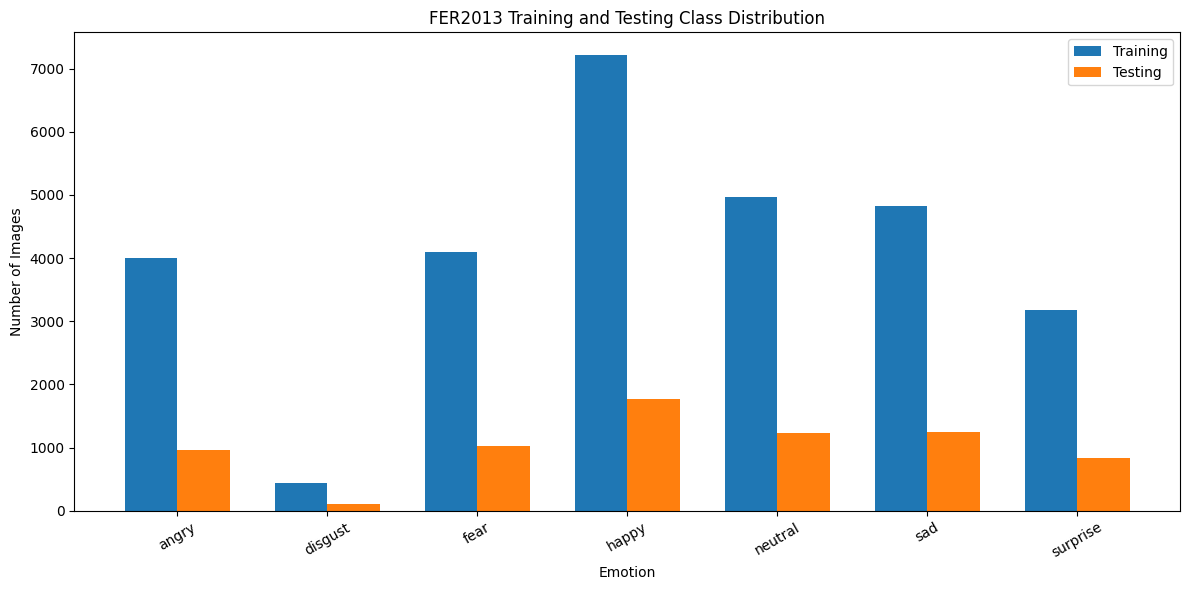

In [54]:
# Plot the number of training and testing samples for each emotion.

plt.figure(figsize=(12, 6))

x = np.arange(len(distribution_df["Emotion"]))
width = 0.35

plt.bar(
    x - width / 2,
    distribution_df["Training"],
    width,
    label="Training"
)

plt.bar(
    x + width / 2,
    distribution_df["Testing"],
    width,
    label="Testing"
)

plt.xticks(
    x,
    distribution_df["Emotion"],
    rotation=30
)

plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.title("FER2013 Training and Testing Class Distribution")

plt.legend()
plt.tight_layout()

plt.show()

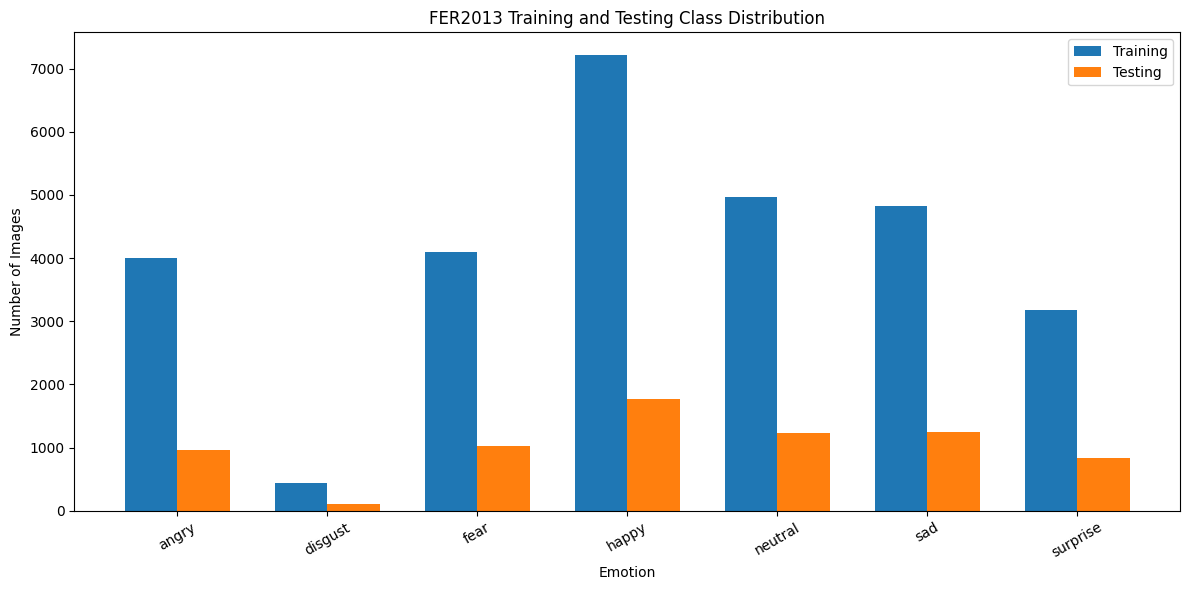

Figure saved to: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\outputs\figures\class_distribution.png


In [55]:
# Create the directory used to store project figures.
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Save the class distribution figure.
distribution_path = FIGURE_DIR / "class_distribution.png"

plt.figure(figsize=(12, 6))

x = np.arange(len(distribution_df["Emotion"]))
width = 0.35

plt.bar(
    x - width / 2,
    distribution_df["Training"],
    width,
    label="Training"
)

plt.bar(
    x + width / 2,
    distribution_df["Testing"],
    width,
    label="Testing"
)

plt.xticks(
    x,
    distribution_df["Emotion"],
    rotation=30
)

plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.title("FER2013 Training and Testing Class Distribution")

plt.legend()
plt.tight_layout()

plt.savefig(
    distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", distribution_path)

### Class Imbalance Observation

The class distribution demonstrates that the FER2013 dataset is not
perfectly balanced across all seven emotion categories.

Some emotions contain substantially more training samples than others.
This imbalance can influence the learning process because the model is
exposed to some classes more frequently than minority classes.

Therefore, accuracy alone may not fully describe the classification
performance. Precision, recall, F1-score, and the confusion matrix will
also be used during model evaluation.

## 3.4 Sample Facial Images

Representative images from each emotion category are visualised to
inspect the appearance and variability of the facial expressions.

Visual inspection is useful for identifying differences in facial
appearance, pose, lighting, and image quality across emotion categories.

In [56]:
# Create a dictionary containing one sample image for each emotion class.

sample_images = {}

for class_index, class_name in enumerate(train_dataset.classes):
    for image_path, label in train_dataset.samples:
        if label == class_index:
            sample_images[class_name] = image_path
            break

print("Sample images selected:")
for emotion, image_path in sample_images.items():
    print(f"{emotion}: {image_path}")

Sample images selected:
angry: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\data\FER2013\train\angry\Training_10118481.jpg
disgust: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\data\FER2013\train\disgust\Training_10371709.jpg
fear: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\data\FER2013\train\fear\Training_10018621.jpg
happy: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\data\FER2013\train\happy\Training_10019449.jpg
neutral: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\data\FER2013\train\neutral\Training_10002154.jpg
sad: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\data\FER2013\train\sad\Training_10022789.jpg
surprise: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\data\FER2013\train\surprise\Training_10013223

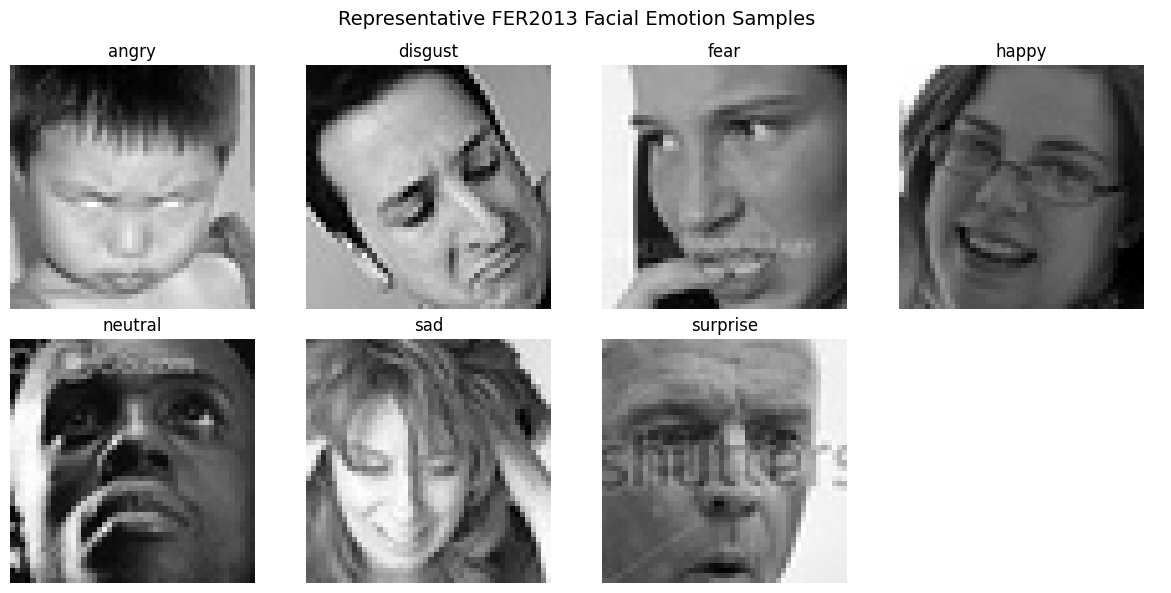

In [57]:
# Display one representative image from each emotion class.

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6)
)

axes = axes.flatten()

for index, class_name in enumerate(train_dataset.classes):

    image_path = sample_images[class_name]

    image = Image.open(image_path)

    axes[index].imshow(
        image,
        cmap="gray"
    )

    axes[index].set_title(class_name)
    axes[index].axis("off")

# Hide the unused subplot.
for index in range(len(train_dataset.classes), len(axes)):
    axes[index].axis("off")

plt.suptitle(
    "Representative FER2013 Facial Emotion Samples",
    fontsize=14
)

plt.tight_layout()
plt.show()

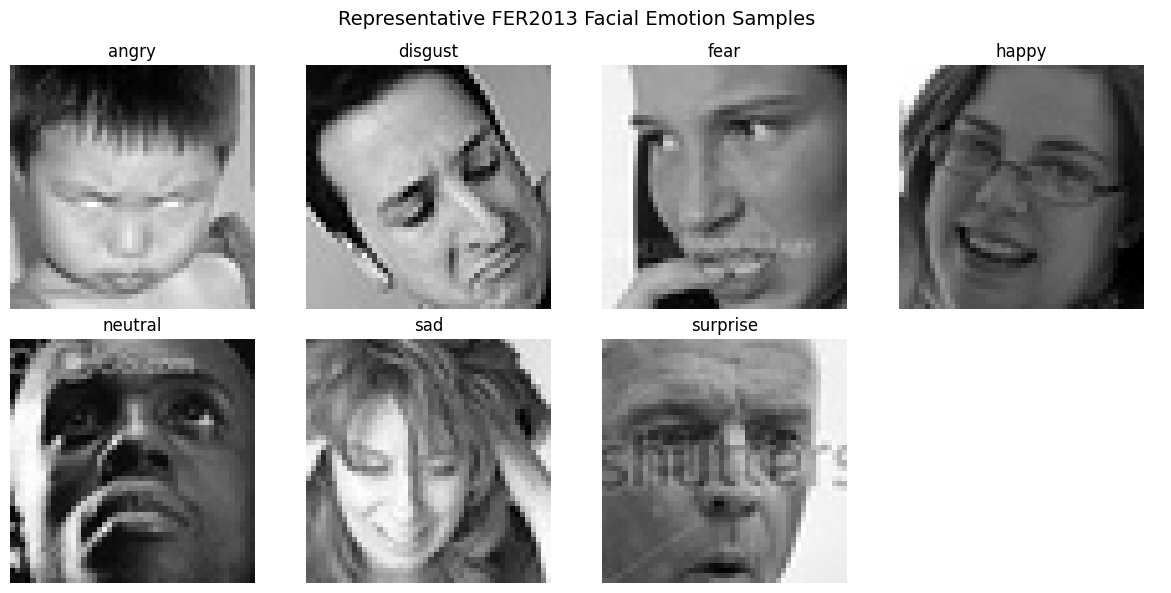

Figure saved to: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\outputs\figures\sample_emotion_images.png


In [58]:
# Save the representative sample image figure.

sample_figure_path = FIGURE_DIR / "sample_emotion_images.png"

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6)
)

axes = axes.flatten()

for index, class_name in enumerate(train_dataset.classes):

    image_path = sample_images[class_name]
    image = Image.open(image_path)

    axes[index].imshow(
        image,
        cmap="gray"
    )

    axes[index].set_title(class_name)
    axes[index].axis("off")

for index in range(len(train_dataset.classes), len(axes)):
    axes[index].axis("off")

plt.suptitle(
    "Representative FER2013 Facial Emotion Samples",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    sample_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", sample_figure_path)

## 3.5 Image Dimensions and Channels

The dimensions and image mode of the FER2013 images are examined
before preprocessing.

The original FER2013 images are commonly provided as small grayscale
facial images. The exact properties of the locally stored dataset are
verified programmatically rather than assumed.

In [59]:
# Inspect the dimensions and image mode of the first training image.

sample_path, sample_label = train_dataset.samples[0]

sample_image = Image.open(sample_path)

print("Image path:", sample_path)
print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)
print("Emotion:", train_dataset.classes[sample_label])

Image path: d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\data\FER2013\train\angry\Training_10118481.jpg
Image size: (48, 48)
Image mode: L
Emotion: angry


## 3.6 EDA Summary

The exploratory analysis confirmed the structure and characteristics of
the FER2013 dataset.

The dataset contains seven emotion categories and separate training and
testing sets. The class distribution shows that the number of samples
varies considerably between emotion categories, indicating the presence
of class imbalance.

The sample images also demonstrate the visual variability of facial
expressions in the dataset. These observations are considered when
designing the preprocessing, augmentation, training, and evaluation
strategies used in the subsequent stages of the project.

# 4. Data Preprocessing

Before training the deep learning model, the facial images are
preprocessed to ensure that they are compatible with the pretrained
EfficientNetV2-S architecture.

The preprocessing pipeline includes:

- Converting grayscale images to RGB.
- Resizing images.
- Data augmentation (training only).
- Tensor conversion.
- Image normalization.

Different preprocessing pipelines are applied to the training and
testing datasets.

## 4.1 Why Convert Grayscale Images to RGB?

The original FER2013 images are grayscale images.

However, the pretrained EfficientNetV2-S model was trained on the
ImageNet dataset, which contains RGB images.

Therefore, grayscale images are converted into three-channel RGB images
before being passed into the network.

## 4.2 Image Processing Configuration

The following preprocessing configuration is used throughout the
project.

In [60]:
# ==========================================================
# Image Processing Configuration
# ==========================================================

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = 2

print("Image Size :", IMAGE_SIZE)
print("Batch Size :", BATCH_SIZE)

Image Size : 224
Batch Size : 32


### Why 224 × 224?

EfficientNetV2-S was pretrained using ImageNet images.

Therefore, facial images are resized to 224 × 224 pixels before
training.

Using the same input resolution allows pretrained weights to be used
effectively through transfer learning.

## 4.3 Image Normalization

Image normalization improves training stability.

Because EfficientNetV2-S is pretrained on ImageNet, the same
normalization statistics are used.

In [61]:
# ==========================================================
# ImageNet Normalization Parameters
# ==========================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]

IMAGENET_STD = [0.229, 0.224, 0.225]

print("Normalization configured.")

Normalization configured.


In [62]:
# ==========================================================
# Training Image Transformations
# ==========================================================

train_transform = transforms.Compose([

    # Convert grayscale images to RGB.
    transforms.Grayscale(num_output_channels=3),

    # Resize images.
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Random horizontal flip.
    transforms.RandomHorizontalFlip(p=0.5),

    # Small random rotation.
    transforms.RandomRotation(10),

    # Small affine transformation.
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),

    # Convert image to tensor.
    transforms.ToTensor(),

    # Normalize image.
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )

])

In [63]:
# ==========================================================
# Testing Image Transformations
# ==========================================================

test_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )

])

### Why is Data Augmentation Applied Only to the Training Set?

Data augmentation artificially increases the diversity of the training
images and improves model generalisation.

The testing dataset must remain unchanged because it represents unseen
data used for unbiased model evaluation.

In [64]:
# ==========================================================
# Reload datasets with preprocessing transformations.
# ==========================================================

train_dataset = datasets.ImageFolder(

    root=TRAIN_DIR,

    transform=train_transform

)

test_dataset = datasets.ImageFolder(

    root=TEST_DIR,

    transform=test_transform

)

print("Datasets loaded with preprocessing pipeline.")

Datasets loaded with preprocessing pipeline.


# 5. DataLoader Preparation

PyTorch DataLoaders are created to load images in mini-batches during
training and evaluation.

Mini-batch learning improves computational efficiency and enables
parallel data loading.

In [65]:
# ==========================================================
# Training DataLoader
# ==========================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True

)

# ==========================================================
# Testing DataLoader
# ==========================================================

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True

)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [66]:
images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)

print("Labels Shape :", labels.shape)

print("Data Type :", images.dtype)

d:\MSc_Comp_Science_SFU\SEMII\AI_&_ML\Assignments\FER2013-Facial-Emotion-Recognition\.venv\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])
Data Type : torch.float32


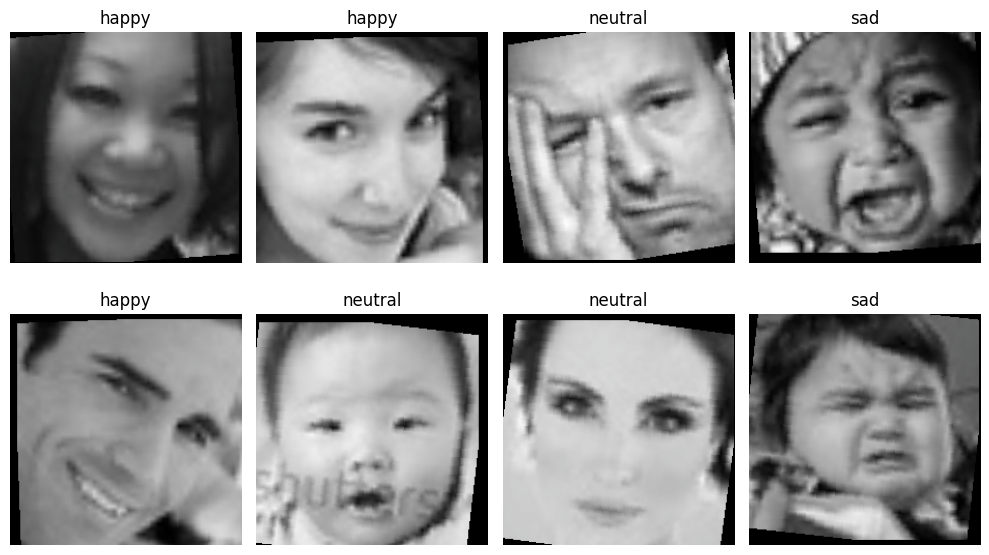

In [67]:
# ==========================================================
# Visualise one mini-batch
# ==========================================================

fig, axes = plt.subplots(2,4,figsize=(10,6))

axes = axes.flatten()

for i in range(8):

    img = images[i]

    img = img.permute(1,2,0).numpy()

    img = img * IMAGENET_STD + IMAGENET_MEAN

    img = np.clip(img,0,1)

    axes[i].imshow(img)

    axes[i].set_title(

        train_dataset.classes[
            labels[i]
        ]

    )

    axes[i].axis("off")

plt.tight_layout()

plt.show()

# 6. Baseline Model Development

This section develops the baseline facial emotion recognition model.

Instead of training a convolutional neural network from scratch, a
pretrained EfficientNetV2-S model is adopted through transfer learning.

Transfer learning reduces training time and generally improves
classification performance because the model has already learned useful
visual representations from the large-scale ImageNet dataset.

In [68]:
# Import pretrained EfficientNetV2-S.

from torchvision.models import (
    efficientnet_v2_s,
    EfficientNet_V2_S_Weights
)

## 6.1 Why Transfer Learning?

Training a deep convolutional neural network from scratch generally
requires a very large dataset and substantial computational resources.

Instead, transfer learning enables previously learned visual features
to be reused for the FER2013 emotion recognition task.

This approach is particularly suitable because FER2013 is relatively
small compared with ImageNet.

In [69]:
# Load ImageNet pretrained EfficientNetV2-S.

weights = EfficientNet_V2_S_Weights.DEFAULT

model = efficientnet_v2_s(
    weights=weights
)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to C:\Users\swunnthut.wonn/.cache\torch\hub\checkpoints\efficientnet_v2_s-dd5fe13b.pth


100.0%


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [75]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 3, 224, 224)
)

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 1000]                 --
├─Sequential: 1-1                                       [1, 1280, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                        [1, 24, 112, 112]         --
│    │    └─Conv2d: 3-1                                 [1, 24, 112, 112]         648
│    │    └─BatchNorm2d: 3-2                            [1, 24, 112, 112]         48
│    │    └─SiLU: 3-3                                   [1, 24, 112, 112]         --
│    └─Sequential: 2-2                                  [1, 24, 112, 112]         --
│    │    └─FusedMBConv: 3-4                            [1, 24, 112, 112]         5,232
│    │    └─FusedMBConv: 3-5                            [1, 24, 112, 112]         5,232
│    └─Sequential: 2-3                                  [1, 48, 56, 56]           --
│    │    └─FusedMBConv: 3-6                         

### Model Verification

A random input tensor is passed through the modified network to verify
that the model correctly produces seven output logits corresponding to
the seven emotion categories.

In [76]:
total = sum(

    p.numel()

    for p in model.parameters()

)

trainable = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

print(f"Total Parameters : {total:,}")

print(f"Trainable : {trainable:,}")

Total Parameters : 21,458,488
Trainable : 21,458,488


## 6.3 Model Complexity

The number of trainable parameters provides an indication of the model
complexity and computational requirements.

EfficientNetV2-S achieves a favourable balance between model size and
classification accuracy, making it appropriate for this project.